# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


# Etapa 1: Relize os passos que vimos no módulo 14, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [3]:
#A) seu código aqui
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    object 
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 10.4+ KB


Nota-se que a coluna 'Income' está com o tipo object. Por ser uma coluna numerica, ela deveria ser do tipo float. Portanto, vou fazer esta alteração.

In [4]:
# Remove o ponto 
df['Income'] = df['Income'].astype(str).str.replace('.','', regex=False)

# Troca a virgula por ponto
df['Income'] = df['Income'].astype(str).str.replace(',','.', regex=False)

# Converte para float
df['Income'] = df['Income'].astype(float)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

A partir do df.info() é possivel ver que a coluna 'Age' possui 34 dados faltantes

In [6]:
#seu código aqui
# Printa média, mediana e outros valores estatísticos
print('Média:',df['Age'].mean())
print('Mediana:',df['Age'].median())
df['Age'].describe()

Média: 37.50769230769231
Mediana: 36.0


count    130.000000
mean      37.507692
std        8.500110
min       25.000000
25%       30.000000
50%       36.000000
75%       45.000000
max       53.000000
Name: Age, dtype: float64

Não há uma diferença significativa entre a média e a mediana da coluna 'Age', portanto irei substituir os valores faltantes pela mediana

In [7]:
# Completa os valores nulos com a mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

# Confere se ainda há valores nulos
print('Quantidade de valores nulos:',df['Age'].isna().sum())
df.info()

Quantidade de valores nulos: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 164 non-null    float64
 1   Gender              164 non-null    object 
 2   Income              164 non-null    float64
 3   Education           164 non-null    object 
 4   Marital Status      164 non-null    object 
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    object 
 7   Credit Score        164 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 10.4+ KB


**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

In [8]:
#seu código aqui
# Percorre todas as colunas e printa seus valores unicos
for i in ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']:
    print(df[i].unique(),'\n')

['Female' 'Male'] 

["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"] 

['Single' 'Married'] 

['Rented' 'Owned'] 

['High' 'Average' 'Low'] 



Nota-se que não há valores digitados incorretamentes

# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

In [9]:
#seu código aqui
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.195122,83765.243902,0.652439
std,7.586619,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,36.000000,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


Vemos que tanto a coluna 'Age' quanto a coluna 'Income' são bem balanceadas e não possuem outliers. A média é muito proxima da mediana

### Analise da coluna 'Number of Children'

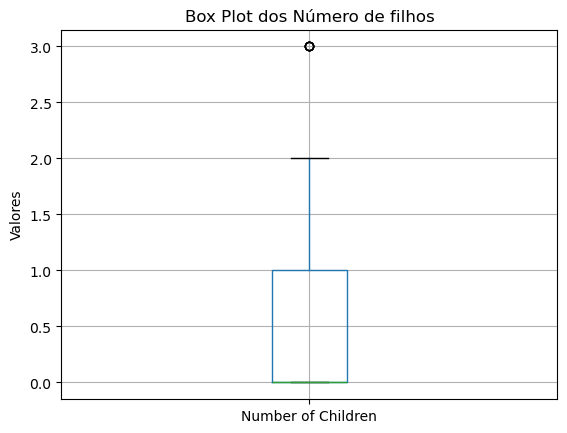

In [10]:
# Plota o gráfico Boxplot
df.boxplot(column='Number of Children')
plt.title('Box Plot dos Número de filhos')
plt.ylabel('Valores')
plt.show()

In [11]:
Q1 = df['Number of Children'].quantile(0.25)
Q3 = df['Number of Children'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print('Primeiro quartil:',Q1,'\n')
print('Terceiro quartil:',Q3,'\n')
print('IQR:',IQR,'\n')
print('Limite inferior:',limite_inferior,' ')
print('Valor mínimo da coluna Number of Children:', df['Number of Children'].min(),'\n')
print('Limite superior:',limite_superior, ' ')
print('Valor máximo da coluna Number of Children:',df['Number of Children'].max())

Primeiro quartil: 0.0 

Terceiro quartil: 1.0 

IQR: 1.0 

Limite inferior: -1.5  
Valor mínimo da coluna Number of Children: 0 

Limite superior: 2.5  
Valor máximo da coluna Number of Children: 3


A coluna 'Number of Children' não é balanceada. Mais de 50% da coluna é 0. Isso não necessáriamente é um problema, apenas indica que a maioria da base de dados não possui filhos.

Vemos no gráfico do boxplot e nos cálculos, que o valor 3 é considerado outlier. Apesar disso, eu não irei removê-los, pois 3 é uma quantidade de filhos aceitável, ou seja, não é um valor extremamente alto. Na verdade, considerar 3 como outlier é um erro. Portanto aqui também não realizarei alterações

**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

### Analise da variável 'Gender'

Gender
Female    52.439024
Male      47.560976
Name: proportion, dtype: float64


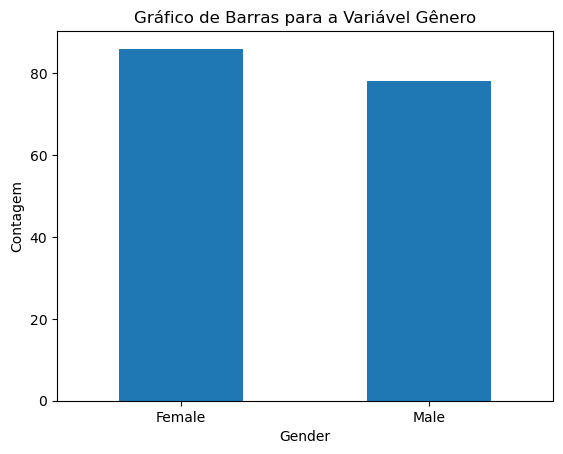

In [12]:
#seu código aqui

# calcula a porcentagem de Genero
print(df['Gender'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Gender'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Gênero')
plt.xlabel('Gender')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

Observa-se que a variável Gênero está bem balanceada, com proporções semelhantes entre homens e mulheres. Essa distribuição equilibrada é importante, pois reduz o risco de viés no modelo e contribui para uma aprendizagem mais representativa dos diferentes grupos.

### Analise da variável 'Education'

Education
Bachelor's Degree      25.609756
Master's Degree        21.951220
Doctorate              18.902439
High School Diploma    18.292683
Associate's Degree     15.243902
Name: proportion, dtype: float64


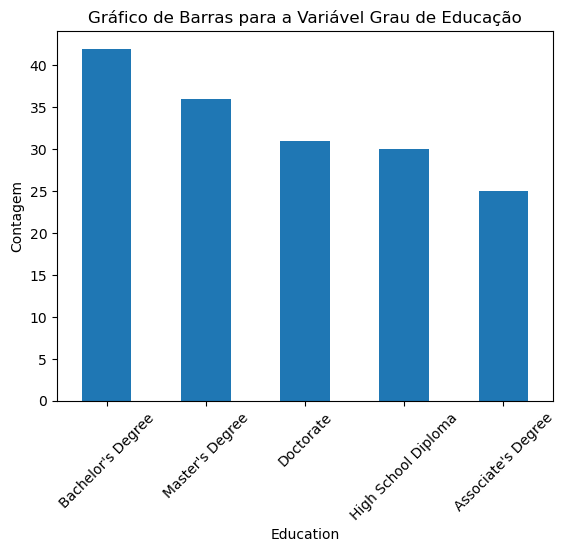

In [13]:
# calcula a porcentagem de Educação
print(df['Education'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Education'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Grau de Educação')
plt.xlabel('Education')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

Observa-se que a variável 'Education' está bem distribuida, com proporções entre 15% e 25%. Sem haver uma categoria de se destaca demais em relação às outras.

### Analise da variável 'Marital Status'

Marital Status
Married    53.04878
Single     46.95122
Name: proportion, dtype: float64


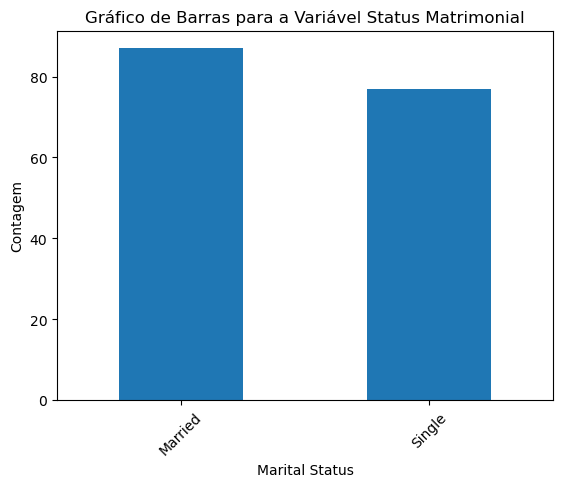

In [14]:
# calcula a porcentagem de Matrimonio
print(df['Marital Status'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Marital Status'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Status Matrimonial')
plt.xlabel('Marital Status')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

Observa-se que a variável Marital Status está bem balanceada, com proporções semelhantes entre casados e solteiros

### Analise da variável 'Home Ownership'

Home Ownership
Owned     67.682927
Rented    32.317073
Name: proportion, dtype: float64


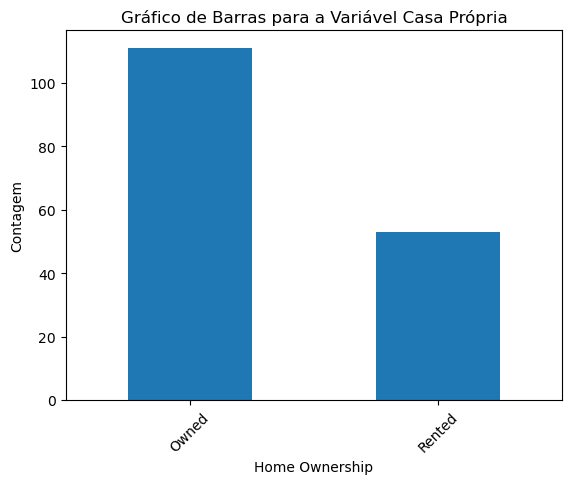

In [15]:
# calcula a porcentagem de Casa Própria
print(df['Home Ownership'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Home Ownership'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Casa Própria')
plt.xlabel('Home Ownership')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

Aqui já é possível observar um desbalanceamente. Pessoas com casas próprias representam dois terços da base enquanto que um terço possui casas alugadas

### Analise da variável 'Home Ownership'

Credit Score
High       68.902439
Average    21.951220
Low         9.146341
Name: proportion, dtype: float64


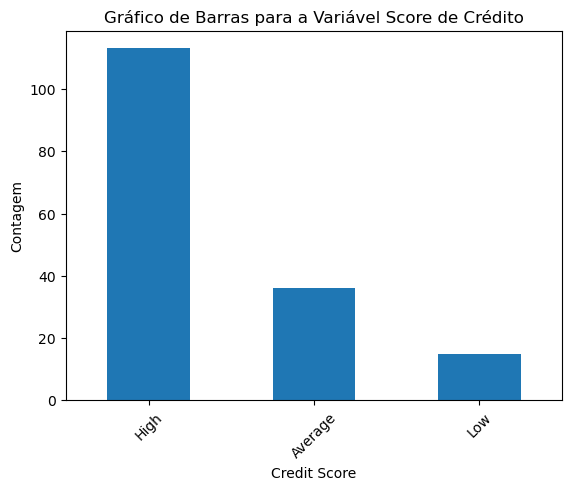

In [16]:
# calcula a porcentagem de Credit Score
print(df['Credit Score'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Credit Score'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Score de Crédito')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

A variável 'Credit Score' (variável a ser predita) está bem desbalanceada, sendo que uma das categorias possui praticamente 70% da base de dados

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

Não encontrei colunas com outliers

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



### Existe relação entre a idade e o status civil?

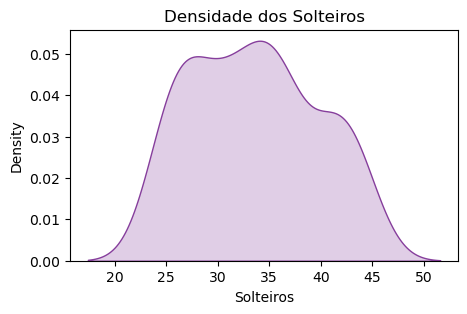

In [17]:
# Separa apenas os solteiros
df_solteiro = df[df['Marital Status']=='Single']
# Plota histograma
plt.figure(figsize=(5, 3))
sns.kdeplot(df_solteiro['Age'], fill=True, color='#863e9c')
plt.title('Densidade dos Solteiros')
plt.xlabel('Solteiros')
plt.show()

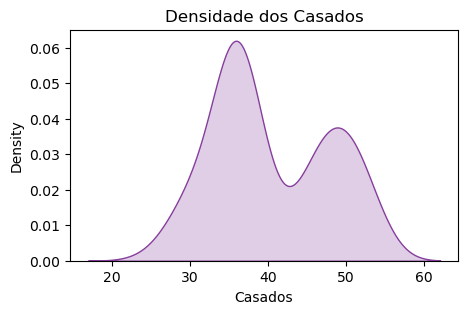

In [18]:
# Separa apenas os casados
df_solteiro = df[df['Marital Status']=='Married']
# Plota histograma
plt.figure(figsize=(5, 3))
sns.kdeplot(df_solteiro['Age'], fill=True, color='#863e9c')
plt.title('Densidade dos Casados')
plt.xlabel('Casados')
plt.show()

A partir dos gráficos é possível concluir que sim, há uma relação entre idade e estado civel. Como era de se esperar, as pessoas casadas tende a serem mais velhas, enquanto que as solteiras tendem a serem mais novas.

### Qual a relação entre o score de crédito e o nível de escolaridade?

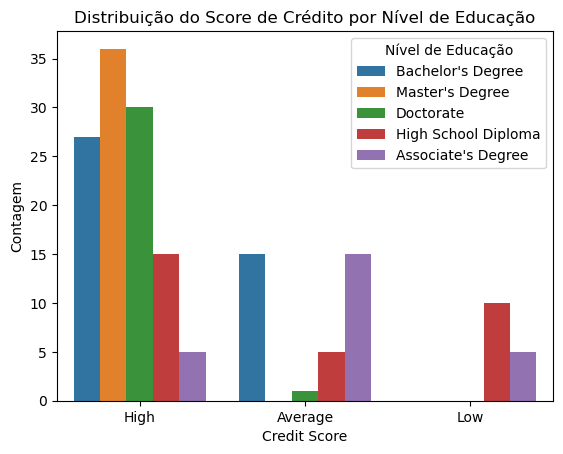

In [19]:
# Countplot com legenda
sns.countplot(x='Credit Score', hue='Education', data=df)
plt.title('Distribuição do Score de Crédito por Nível de Educação')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
plt.legend(title='Nível de Educação')
plt.show()

A partir do gráfico, observa-se que quanto maior o nível de escolaridade, maior tende a ser o Score de Crédito. Nota-se que, na categoria "Low", concentram-se apenas pessoas com os menores níveis de escolaridade, enquanto indivíduos com Mestrado ou Doutorado só aparecem na categoria "High".

### O salário parece influenciar na idade?

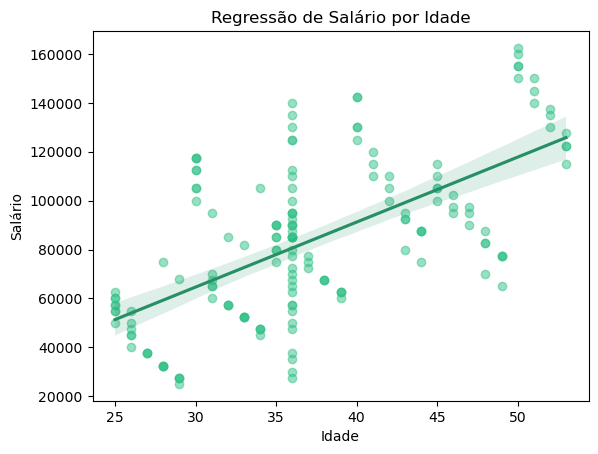

In [20]:
# Gráfico de Regressão
sns.regplot(x='Age', y='Income', data=df, color='#278f65', scatter_kws={'alpha': 0.5, 'color': '#34c289'})
plt.title('Regressão de Salário por Idade')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.show()

Eu não diria que **o salário** influencia na idade. Na verdade acredito que seja o contrário, é a idede que influencia no salário.

De qualquer forma, fica claro no gráfico que quanto mais velho, maior tende a ser o salário.

### O salário parece influenciar no Score de Crédito?

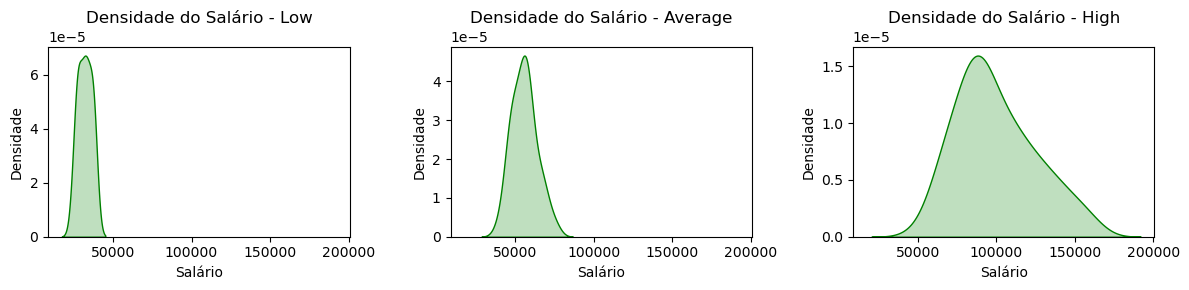

In [21]:
# Uma imagem com 3 gráficos dentro, 1 linhas e 3 colunas
fig, axs = plt.subplots(1, 3, figsize=(12, 3), sharex=True)
axs = axs.ravel()  # transforma a matriz 1x3 em vetor (para iterar facilmente)

# Plota os 3 subplots, um para cada nível de score
for ax, i in zip(axs, ['Low', 'Average', 'High']):
    df_score = df[df['Credit Score'] == i]
    sns.kdeplot(df_score['Income'], fill=True, color='green', ax=ax)
    ax.set_title(f'Densidade do Salário - {i}')
    ax.set_xlabel('Salário')
    ax.set_ylabel('Densidade')
    
plt.tight_layout()
plt.show()

Sim, fica evidente pelos gráficos que quanto maior o salário, maior o score.

### Clientes com casa própria tendem a ter um score mais alto?

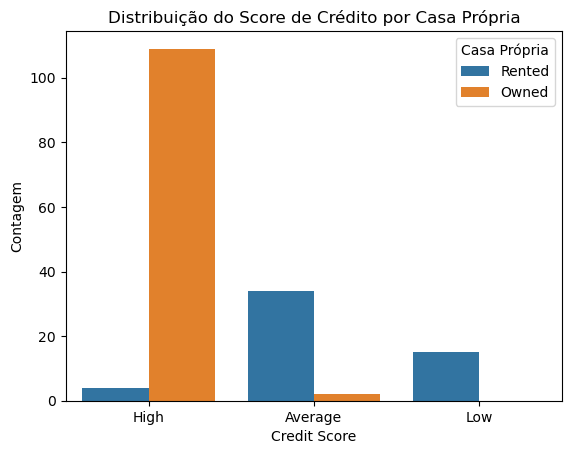

In [22]:
# Countplot com legenda
sns.countplot(x='Credit Score', hue='Home Ownership', data=df)
plt.title('Distribuição do Score de Crédito por Casa Própria')
plt.xlabel('Credit Score')
plt.ylabel('Contagem')
plt.legend(title='Casa Própria')
plt.show()

Novamente um clara relação. Pessoas com casa própria tendem a ter Score mais alto, enquanto que pessoas com casa alugada tendem a ter Score mediano ou baixo

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

### Pessoas casadas tendem a ter mais filhos?

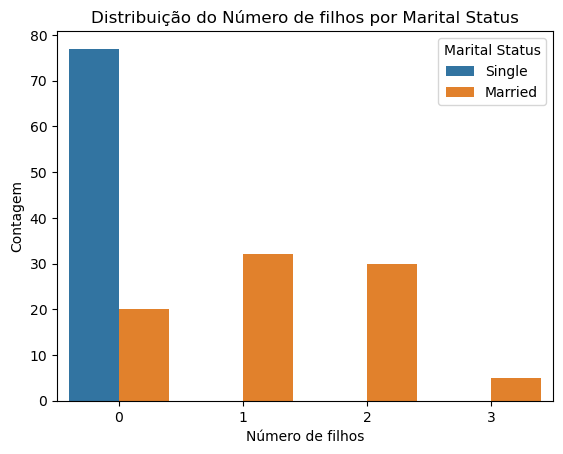

In [23]:
# Countplot com legenda
sns.countplot(x='Number of Children', hue='Marital Status', data=df)
plt.title('Distribuição do Número de filhos por Marital Status')
plt.xlabel('Número de filhos')
plt.ylabel('Contagem')
plt.legend(title='Marital Status')
plt.show()

Sim, 100% das pessoas que possuem filhos são casadas. E 100% dos solteiros não possuem filhos.

### Pessoas casadas tendem a ter casa própria?

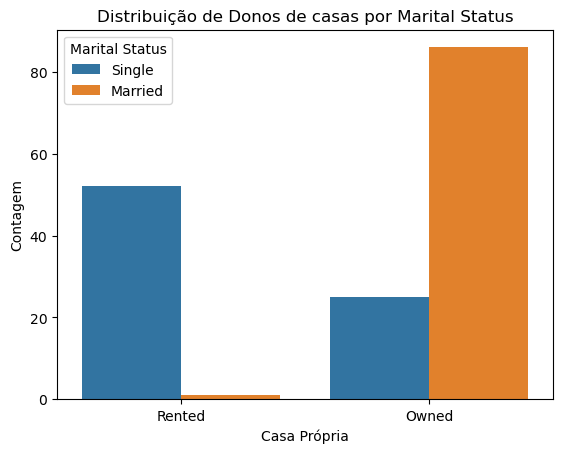

In [24]:
# Countplot com legenda
sns.countplot(x='Home Ownership', hue='Marital Status', data=df)
plt.title('Distribuição de Donos de casas por Marital Status')
plt.xlabel('Casa Própria')
plt.ylabel('Contagem')
plt.legend(title='Marital Status')
plt.show()

Novamente vemos que estas duas variáveis possuem relação. A maioria das pessoas casadas possuem casa própria enquanto que os solteiros estão mais distribuidos entre casa própria e alugada.

### O salário tem alguma relação com a quantidade de filhos?

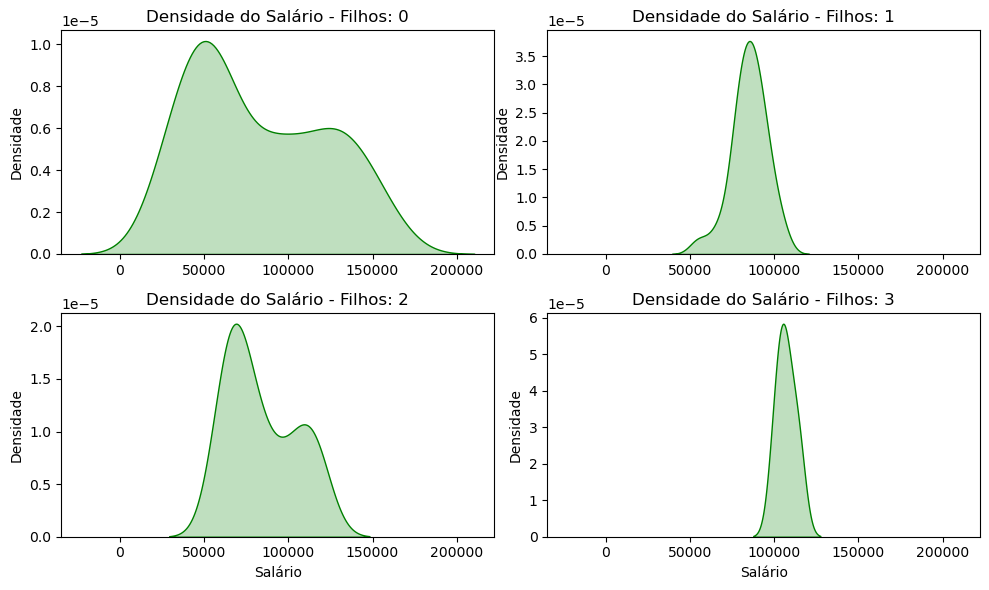

In [25]:
# Uma imagem com 4 gráficos dentro, 2 linhas e 2 colunas
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axs = axs.ravel()  # transforma a matriz 2x2 em vetor (para iterar facilmente)

# Plota os 4 subplots, um para cada quantidade de filhos
for ax, i in zip(axs, [0, 1, 2, 3]):
    df_score = df[df['Number of Children'] == i]
    sns.kdeplot(df_score['Income'], fill=True, color='green', ax=ax)
    ax.set_title(f'Densidade do Salário - Filhos: {i}')
    ax.set_xlabel('Salário')
    ax.set_ylabel('Densidade')
    ax.tick_params(labelbottom=True)
    
plt.tight_layout()
plt.show()

Sim, pessoas sem filhos tendem a ter salários menores enquanto que pessoas com filhos tende a ter salários maiores.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

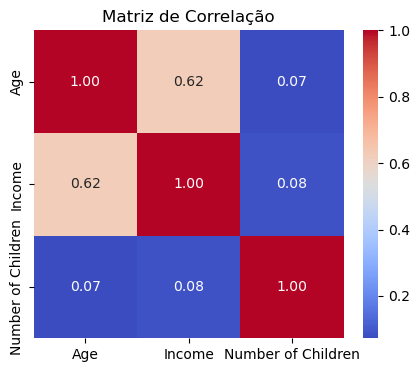

In [26]:
#seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Sim, a partir do gráfico é possível inferir que o salário possui uma alta correlação com a idade. Que é uma conclusão que já haviamos constatado anteriormente

**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

Os atributos catégóricos são: 'Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score'.

Para as variáveis 'Gender', 'Marital Status' e 'Home Ownership' irei utilizar o método One Hot Encoder.

E para as variáveis 'Education' e 'Credit Score' irei utilizar o método Label Encoder. 

In [27]:
#seu código aqui
# Aplicar o One Hot Encoder para a coluna "Gender"
df = pd.get_dummies(df, columns=['Gender'], prefix='Gender', drop_first=True)

# Aplicar o One Hot Encoder para a coluna "Home Ownership"
df = pd.get_dummies(df, columns=['Home Ownership'], prefix='Home Ownership', drop_first=True)

# Aplicar o One Hot Encoder para a coluna "Marital Status"
df = pd.get_dummies(df, columns=['Marital Status'], prefix='Marital Status', drop_first=True)

# Transforma as colunas 'Gender', 'Marital Status' e 'Home Ownership' de bool para int
for column in ['Gender_Male', 'Home Ownership_Rented', 'Marital Status_Single']:
    df[column] = df[column].astype(int)

# Criando uma instância do Label Encoder
label_encoder = LabelEncoder()

# Aplicando o Label Encoder para a coluna "Education"
df['Education_encoded'] = label_encoder.fit_transform(df['Education'])

# O Label Encoder gerou numeros de acordo com a ordem alfabética e não é isso que eu quero. Eu quero que o High School Diploma seja 0, 
# Associate's Degree seja 1, Bachelor's Degree seja 2, Master's Degree seja 3 e Doctorate seja 4
# Por isso vou uasr o map para corrigir isso
df['Education_encoded'] = df['Education'].map({'High School Diploma':0, "Associate's Degree":1,
                                                     "Bachelor's Degree":2, "Master's Degree":3, 'Doctorate':4})

# Aplicando o Label Encoder para a coluna "Credit Score"
df['Credit Score_encoded'] = label_encoder.fit_transform(df['Credit Score'])

# O Label Encoder gerou numeros de acordo com a ordem alfabética e não é isso que eu quero. Eu quero que o Low seja 0, Average seja 1 e High seja 2
# Por isso vou uasr o map para corrigir isso
df['Credit Score_encoded'] = df['Credit Score'].map({'Low':0, 'Average':1, 'High':2})

In [28]:
# Joga fora as colunas originais
df = df.drop(['Education'], axis=1)
df = df.drop(['Credit Score'], axis=1)

df.head()

,Age,Income,Number of Children,Gender_Male,Home Ownership_Rented,Marital Status_Single,Education_encoded,Credit Score_encoded
0,25.0,50000.0,0,0,1,1,2,2
1,30.0,100000.0,2,1,0,0,3,2
2,35.0,75000.0,1,0,0,0,4,2
3,40.0,125000.0,0,1,0,1,0,2
4,45.0,100000.0,3,0,0,0,2,2


**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

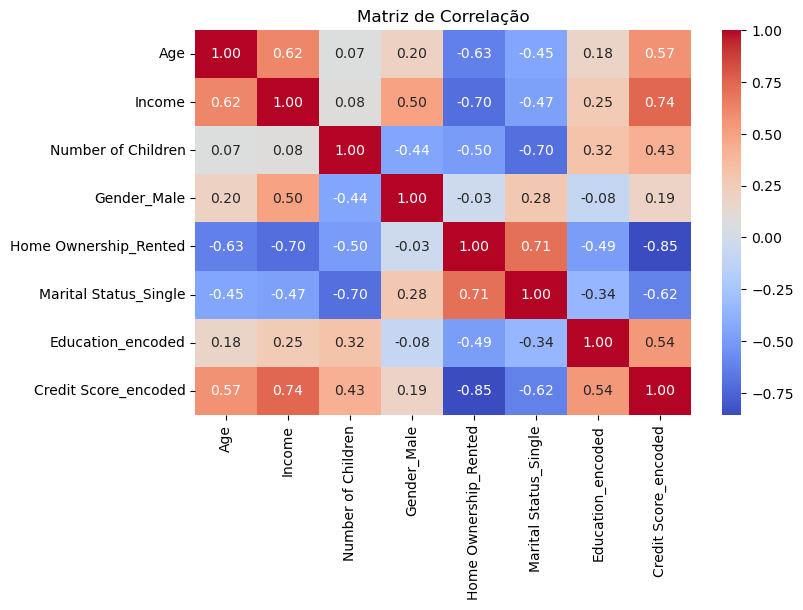

In [29]:
#seu código aqui
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Diversas novas variáveis com forte correlação surgiram. Com relação a variável 'Credit Score', vemos que 'Income' tem uma forte correlação. Outra que apareceu também é a variável 'Home Ownership', esta tem uma correlação fortíssima, indicando que pessoas com casa própria tem um Score maior, por isso a correlação negativa.

Outra correlação que apareceu e que já haviamos constatado é a entre 'Home Ownership' e 'Marital Status'. Observa-se que passoas casadas tende a ter casa própria.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [30]:
#seu código aqui

# Separar os dados em features (X) e o alvo (y)
X = df.drop('Credit Score_encoded', axis=1)  # Considerando que 'Credit Score_encoded' é a coluna a ser predita
y = df['Credit Score_encoded']

# Separar os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

print('Tamanho do X_train:', X_train.shape)
print('Tamanho do y_train:', y_train.shape)
print('Tamanho do X_test:', X_test.shape)
print('Tamanho do y_test:', y_test.shape)

Tamanho do X_train: (123, 7)
Tamanho do y_train: (123,)
Tamanho do X_test: (41, 7)
Tamanho do y_test: (41,)


Vemos que os tamanhos estão corretos

**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

Credit Score_encoded
2    68.902439
1    21.951220
0     9.146341
Name: proportion, dtype: float64


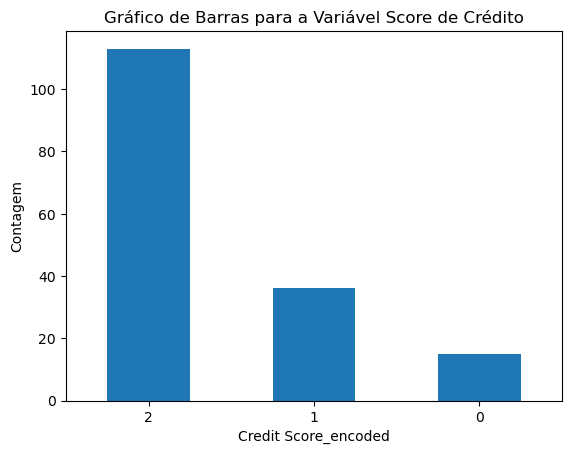

In [31]:
#seu código aqui
# calcula a porcentagem de Credit Score
print(df['Credit Score_encoded'].value_counts(normalize=True) * 100)

# PLota o gráfico de barra
ax = df['Credit Score_encoded'].value_counts().plot(kind='bar')
plt.title('Gráfico de Barras para a Variável Score de Crédito')
plt.xlabel('Credit Score_encoded')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

A coluna Credit "Score_encoded" **não está balanceada**. Há bem mais linhas na categoria 2 do que nas demais

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [32]:
#seu código aqui

# Criar uma instância do SMOTE
smote = SMOTE(random_state=11)

# Aplicar o SMOTE aos dados de treinamento (X_train, y_train)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Verificar a distribuição das classes após o balanceamento
print("Distribuição das classes após o balanceamento:")
print(X_train_balanced.shape)
print(y_train_balanced.value_counts())

Distribuição das classes após o balanceamento:
(243, 7)
Credit Score_encoded
2    81
1    81
0    81
Name: count, dtype: int64


In [ ]:
X_train_balanced.to_csv("X_train_balanced.csv", index=False, encoding="utf-8")
df.to_csv("y_train_balanced.csv", index=False, encoding="utf-8")
df.to_csv("X_test.csv", index=False, encoding="utf-8")
df.to_csv("y_test.csv", index=False, encoding="utf-8")

É possível ver que agora está balanceado. Cada categoria representa 1/3 das linhas